In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import plotly.express as px

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving online_retail.csv to online_retail (1).csv
Saving Mall_Customers.csv to Mall_Customers (1).csv


In [3]:
import os
os.listdir()

['.config',
 'online_retail (1).csv',
 'online_retail.csv',
 'Mall_Customers (1).csv',
 'Mall_Customers.csv',
 'sample_data']

In [4]:
import os

# Delete duplicate files
for file in ["online_retail (1).csv", "Mall_Customers (1).csv"]:
    if os.path.exists(file):
        os.remove(file)
        print(f"Deleted: {file}")
    else:
        print(f"Not found: {file}")


Deleted: online_retail (1).csv
Deleted: Mall_Customers (1).csv


In [6]:
import os
os.listdir()

['.config', 'online_retail.csv', 'Mall_Customers.csv', 'sample_data']

In [7]:
import pandas as pd

retail_df = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")
mall_df = pd.read_csv("Mall_Customers.csv")

In [8]:
retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
mall_df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [10]:
print("Online Retail Dataset")
retail_df.info()

print("\n" + "="*50 + "\n")

print("Mall Customers Dataset")
mall_df.info()

Online Retail Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


Mall Customers Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-n

In [11]:
print(retail_df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [12]:
print(mall_df.isnull().sum())

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [13]:
print("Retail Dataset Shape:", retail_df.shape)
print("Mall Dataset Shape:", mall_df.shape)

Retail Dataset Shape: (541909, 8)
Mall Dataset Shape: (200, 5)


In [14]:
retail_df.duplicated().sum()


np.int64(5268)

In [15]:
# Remove duplicate rows
df = retail_df.drop_duplicates()

# Check the new shape
print("Shape after removing duplicates:", df.shape)

# Verify duplicates are removed
print("Remaining duplicates:", df.duplicated().sum())

Shape after removing duplicates: (536641, 8)
Remaining duplicates: 0


In [16]:
# Create a copy
df = retail_df.copy()

# Remove rows with missing CustomerID
df = df.dropna(subset=["CustomerID"])

# Convert CustomerID to integer
df["CustomerID"] = df["CustomerID"].astype(int)

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Remove cancelled invoices
df = df[~df["InvoiceNo"].str.startswith("C")]

# Remove invalid quantities
df = df[df["Quantity"] > 0]

# Remove invalid prices
df = df[df["UnitPrice"] > 0]

# Create TotalAmount column
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

print("Shape after cleaning:", df.shape)

Shape after cleaning: (397884, 9)


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  int64         
 7   Country      397884 non-null  object        
 8   TotalAmount  397884 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 30.4+ MB


In [18]:
mall_df.duplicated().sum()

np.int64(0)

In [19]:
print("Number of Transactions:", len(df))
print("Number of Unique Customers:", df["CustomerID"].nunique())
print("Number of Unique Products:", df["StockCode"].nunique())
print("Number of Countries:", df["Country"].nunique())
print("Total Revenue: ${:,.2f}".format(df["TotalAmount"].sum()))

Number of Transactions: 397884
Number of Unique Customers: 4338
Number of Unique Products: 3665
Number of Countries: 37
Total Revenue: $8,911,407.90


In [20]:
country_sales = (
    df.groupby("Country")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_sales

,TotalAmount
Country,
United Kingdom,7308391.554
Netherlands,285446.340
EIRE,265545.900
Germany,228867.140
France,209024.050
Australia,138521.310
Spain,61577.110
Switzerland,56443.950
Belgium,41196.340


In [21]:
product_sales = (
    df.groupby("Description")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

product_sales

,TotalAmount
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142592.95
WHITE HANGING HEART T-LIGHT HOLDER,100448.15
JUMBO BAG RED RETROSPOT,85220.78
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68844.33
ASSORTED COLOUR BIRD ORNAMENT,56580.34
Manual,53779.93


In [22]:
df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)

monthly_sales = (
    df.groupby("Month")["TotalAmount"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,Month,TotalAmount
0,2010-12,572713.890
1,2011-01,569445.040
2,2011-02,447137.350
3,2011-03,595500.760
4,2011-04,469200.361


In [23]:
df.to_csv("cleaned_online_retail.csv", index=False)
mall_df.to_csv("cleaned_mall_customers.csv", index=False)

In [24]:
# Create snapshot date (one day after the latest transaction)
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Calculate RFM metrics
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

# Rename columns
rfm.columns = ["Recency", "Frequency", "Monetary"]

# Display first 5 rows
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [25]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

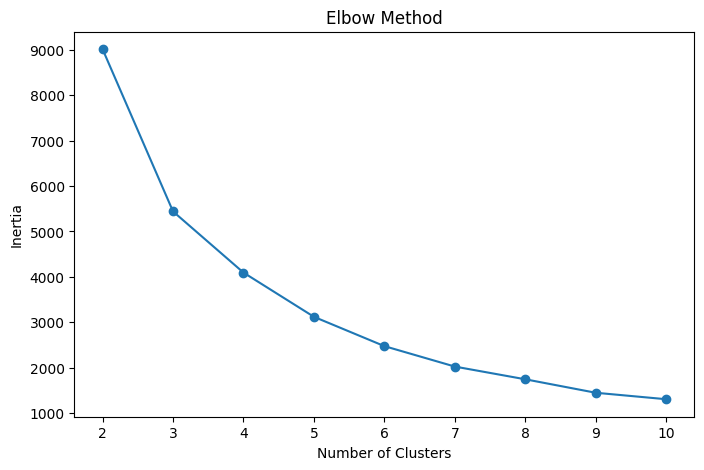

In [27]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [28]:
from sklearn.cluster import KMeans

# Train K-Means with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Assign cluster labels
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

# View first few rows
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,326,1,77183.60,2
12347,2,7,4310.00,0
12348,75,4,1797.24,0
12349,19,1,1757.55,0
12350,310,1,334.40,1


In [29]:
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.95,3.65,1339.07
1,248.56,1.55,478.11
2,15.67,21.29,12831.74
3,6.50,120.50,55312.69
4,7.67,42.83,190863.46


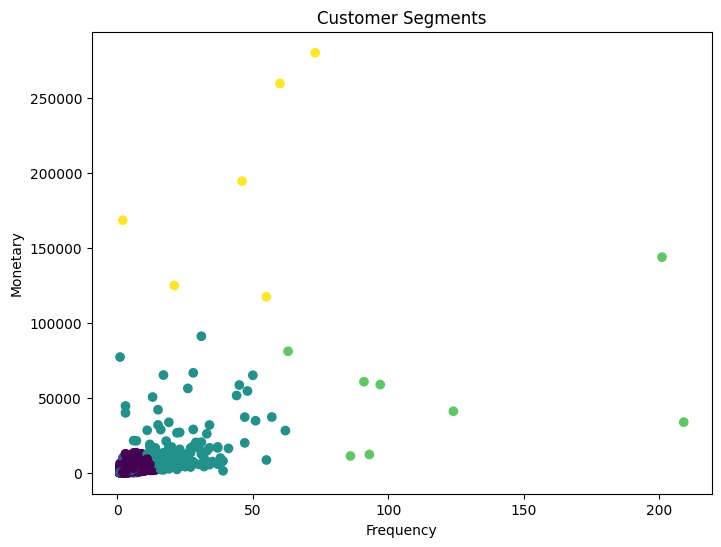

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"],
    cmap="viridis"
)

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Segments")

plt.show()

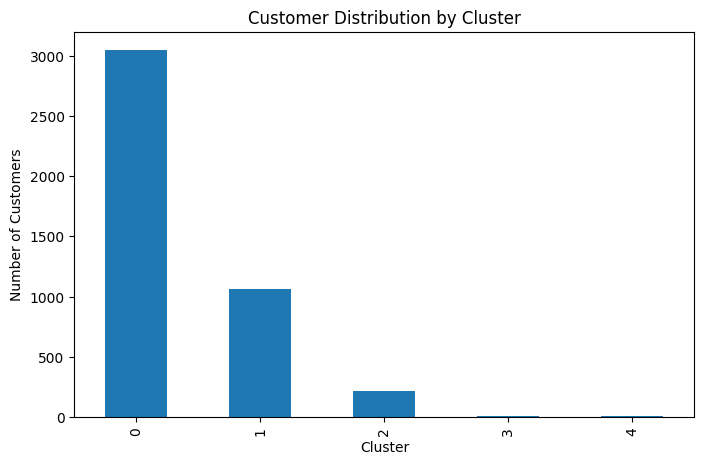

In [31]:
import matplotlib.pyplot as plt

rfm["Cluster"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

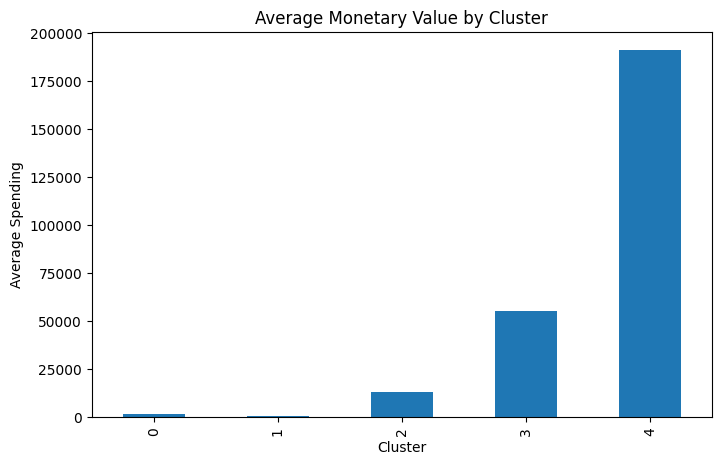

In [32]:
cluster_summary["Monetary"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Monetary Value by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Spending")
plt.show()

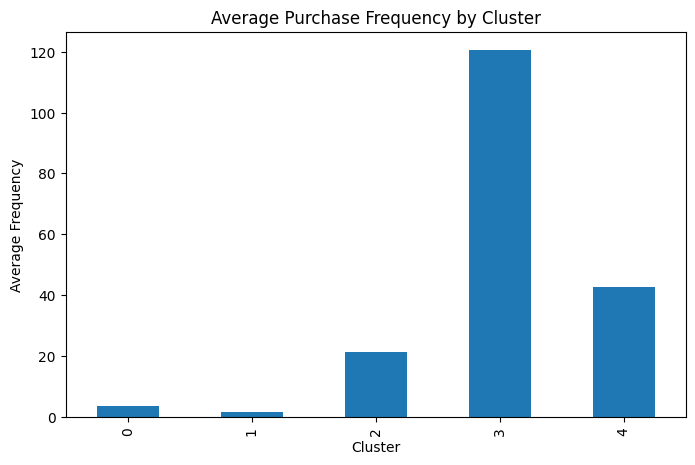

In [33]:
cluster_summary["Frequency"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Purchase Frequency by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Frequency")
plt.show()

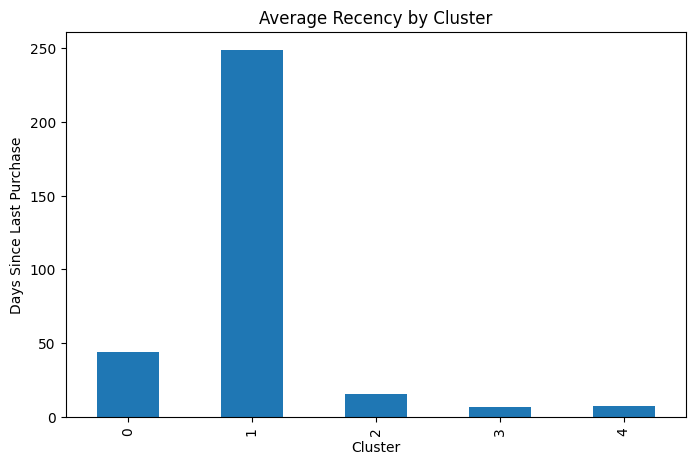

In [34]:
cluster_summary["Recency"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Recency by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Days Since Last Purchase")
plt.show()

In [35]:
# Reset index so CustomerID becomes a column
rfm_final = rfm.reset_index()

# Add segment names
segment_names = {
    0: "Regular Customers",
    1: "At-Risk Customers",
    2: "Loyal Customers",
    3: "VIP Customers",
    4: "Premium Customers"
}

rfm_final["Segment"] = rfm_final["Cluster"].map(segment_names)

# Save CSV
rfm_final.to_csv("Customer_Segmentation.csv", index=False)

In [36]:
from google.colab import files
files.download("Customer_Segmentation.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>